In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [2]:
# PhysiCell Results
# output_folder = '../PhysiCell/results/mechanics_movement/'
# pc_data = pd.read_csv('cell_position_time.csv')
pc_data= pd.read_csv('/home/tntiniak/Work/physicellforbenchmarknewintegrationwithrandy/PhysiCell/mechanics_movement/cell_position_time.csv')
pc_data

,id,x,y,z,velocity,is_motile,migration_speed,mvx,mvy,mvz,dt,persistence_time
0,0.0,0.0,0.0,0.0,0.0,1.0,10.0,0.0,0.0,0.0,0.0,0.01
1,0.0,1.5,0.0,0.0,0.0,1.0,10.0,10.0,0.0,0.0,0.1,0.01
2,0.0,1.5,0.0,0.0,0.0,0.0,10.0,0.0,0.0,0.0,0.2,0.01
3,0.0,1.5,0.0,0.0,0.0,0.0,10.0,0.0,0.0,0.0,0.3,0.01
4,0.0,1.5,0.0,0.0,0.0,0.0,10.0,0.0,0.0,0.0,0.4,0.01
...,...,...,...,...,...,...,...,...,...,...,...,...
96,0.0,1.5,0.0,0.0,0.0,0.0,10.0,0.0,0.0,0.0,9.6,0.01
97,0.0,1.5,0.0,0.0,0.0,0.0,10.0,0.0,0.0,0.0,9.7,0.01
98,0.0,1.5,0.0,0.0,0.0,0.0,10.0,0.0,0.0,0.0,9.8,0.01
99,0.0,1.5,0.0,0.0,0.0,0.0,10.0,0.0,0.0,0.0,9.9,0.01


In [3]:
output_folder = '../Biodynamo/unit_test_mechanics_friction_single/results/'
bd_data =pd.read_csv(output_folder + 'positions.csv',index_col=0,header = None,sep='\t|,',engine='python').rename(columns={1: "x", 2: "y", 3: "z"})
bd_data


,x,y,z
0,,,
0,0,0,0
1,1,0,0
2,1,0,0
3,1,0,0
4,1,0,0
...,...,...,...
95,1,0,0
96,1,0,0
97,1,0,0


In [4]:
bd_data['dx'] = abs(bd_data['x'] - bd_data['x'].shift(1))
bd_data.fillna({"dx":0}, inplace=True)

bd_data['timestep'] = np.arange(0,10,0.1)
bd_data['dt'] =0.1

bd_data['velocity'] = bd_data['dx'] / bd_data['dt']
bd_data.loc['velocity',0] = 0
bd_data

,x,y,z,dx,timestep,dt,velocity,0
0,,,,,,,,
0,0.0,0.0,0.0,0.0,0.0,0.1,0.0,NaN
1,1.0,0.0,0.0,1.0,0.1,0.1,10.0,NaN
2,1.0,0.0,0.0,0.0,0.2,0.1,0.0,NaN
3,1.0,0.0,0.0,0.0,0.3,0.1,0.0,NaN
4,1.0,0.0,0.0,0.0,0.4,0.1,0.0,NaN
...,...,...,...,...,...,...,...,...
96,1.0,0.0,0.0,0.0,9.6,0.1,0.0,NaN
97,1.0,0.0,0.0,0.0,9.7,0.1,0.0,NaN
98,1.0,0.0,0.0,0.0,9.8,0.1,0.0,NaN


In [5]:
output_folder = '../Chaste/unit_test_mechanics_friction/results/'
ch_data = pd.read_csv(output_folder+'node_locations.dat',header = None,names=["timestep","x","y"],sep='\t| ',index_col=None,engine='python')
ch_data

,timestep,x,y
0,0.000000,0,0
1,0.001667,1,0
2,0.003333,1,0
3,0.005000,1,0
4,0.006667,1,0
...,...,...,...
96,0.160000,1,0
97,0.161667,1,0
98,0.163333,1,0
99,0.165000,1,0


In [6]:

ch_data['dx'] = abs(ch_data["x"] - ch_data["x"].shift(1))
ch_data.fillna({"dx":0}, inplace=True)
ch_data['timestep'] = np.arange(0,10.01,0.1)
ch_data['dt'] =0.1
ch_data['velocity'] = ch_data['dx'] / ch_data['dt']
ch_data

,timestep,x,y,dx,dt,velocity
0,0.0,0,0,0.0,0.1,0.0
1,0.1,1,0,1.0,0.1,10.0
2,0.2,1,0,0.0,0.1,0.0
3,0.3,1,0,0.0,0.1,0.0
4,0.4,1,0,0.0,0.1,0.0
...,...,...,...,...,...,...
96,9.6,1,0,0.0,0.1,0.0
97,9.7,1,0,0.0,0.1,0.0
98,9.8,1,0,0.0,0.1,0.0
99,9.9,1,0,0.0,0.1,0.0


In [9]:
output_folder="../Tisim/unit_test_mechanics_friction/"
ts_data = pd.read_csv(output_folder+'mechanical friction.csv',header=0,sep='\t|,',engine='python',names=["dt","velocity"])
ts_data

,dt,velocity
0,0.0,10
1,0.1,0
2,0.2,0
3,0.3,0
4,0.4,0
...,...,...
96,9.6,0
97,9.7,0
98,9.8,0
99,9.9,0


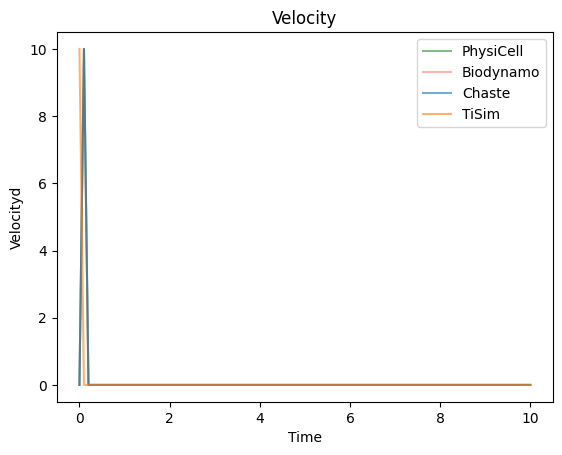

In [26]:
plt.plot(pc_data['dt'],pc_data['mvx'],label="PhysiCell", color= 'green',alpha = 0.5)
plt.plot(bd_data['timestep'],bd_data['velocity'],label="Biodynamo",color= 'red',alpha = 0.3)
plt.plot(ch_data['timestep'],ch_data['velocity'],label="Chaste",alpha = 0.6)
plt.plot(ts_data['dt'],ts_data['velocity'],label="TiSim",alpha = 0.6)
plt.ylabel(ylabel="Velocityd")
plt.xlabel(xlabel="Time")
plt.title("Velocity")
plt.legend()
plt.savefig("mechanics_friction.png",dpi=200)

plt.show()